## Procesamiento de los datos para Machine Leraning

Aplicar las técnicas principales de preprocesamiento de datos para preparar
un dataset del entremiento

## Parte 1. Compresion del problema

Trabajaremos con el DataSet de Titanic, para contruir un modelo que sea capaz de 
predecir si una persona sobrevive o no

In [1]:
# importamos las librerias 
import pandas as pd
import numpy as np

#Librerias de Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#Librerias para graficar

import seaborn as sns
import matplotlib.pyplot as plt

#Libreria de Kaggle
import kagglehub

C:\Users\Fatim\anaconda3\envs\Extraccion9AVS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Descargamos el Dataset de la pagina Kaggle
path = kagglehub.dataset_download("yasserh/titanic-dataset")
path #Imprimimos la ruta

'C:\\Users\\Fatim\\.cache\\kagglehub\\datasets\\yasserh\\titanic-dataset\\versions\\1'

In [3]:
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv") #Creamos el Dataframe

In [4]:
dfTitanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
dfTitanic.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

## Parte 2. Seleccion de Variables Predictoras y Variable Objetivo

La variable objetivo sera: Survived

donde 0 = No sobrevivio 1= Sobrevivio

In [6]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [7]:
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [8]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlacion e Hipotesis

Vamos a identificar la relacion entre variables numericas

nota: La correlacion NO representa la importancia Real de la variable en el modelo

In [9]:
variables_numericas = [
    "Survived",
    "Pclass",
    "SibSp",
    "Parch",
    "Fare"
]

In [10]:
corr = dfTitanic[variables_numericas].corr() #Creamos la matriz de correlacion
corr

,Survived,Pclass,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,0.083081,0.018443,-0.549500
SibSp,-0.035322,0.083081,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.159651,0.216225,1.000000


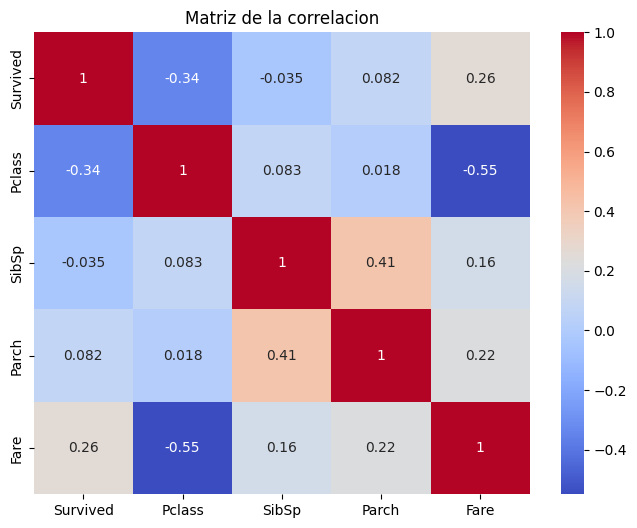

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de la correlacion")
plt.show()

## Parte 4. Variables predictoras.

x---> Aquellas variables que nos ayudan a predecir
y---> Variable objetivo

In [12]:
dfTitanic.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [13]:
columnas= [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked"
]

In [14]:
X = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [15]:
X.columns

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked'], dtype='object')

In [16]:
y.name

'Survived'

In [17]:
y.name #Objetivo

'Survived'

## Parte 5. Limpieza de los datos

Realizemos la imputacion de los datos, donde exitan valores nulos

In [18]:
# Revisamos si existen valores nulos
X.isnull().sum()

Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
dtype: int64

In [19]:
#vamos a imputar los datos para el campo Edad, calculando la mediana
X["Age"] = X["Age"].fillna(
    X["Age"].median()
)

C:\Users\Fatim\AppData\Local\Temp\ipykernel_26440\311828439.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"] = X["Age"].fillna(


In [20]:
#Vamos imputar los datos para el campo Emberked, calculando la moda

X["Embarked"]= X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

C:\Users\Fatim\AppData\Local\Temp\ipykernel_26440\3510416700.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Embarked"]= X["Embarked"].fillna(


In [21]:
#Revisamos si existen valores nulos
X.isnull().sum()

Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
dtype: int64

## Parte 6. Normalizamos los datos categoricos(texto)
Los algoritmos de ML no entienden texto.

In [22]:
X.head(2)

,Pclass,Sex,Age,Fare,Embarked
0,3,male,22.0,7.2500,S
1,1,female,38.0,71.2833,C


In [23]:
#One hot Encoding
X = pd.get_dummies(
    X,
    columns=[
        "Sex",
        "Embarked"
    ],
    drop_first= True
)

In [24]:
X.head(2)

,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,7.2500,True,False,True
1,1,38.0,71.2833,False,False,False


## Parte 7. Division de los datos

No debemos entrenar y evaluar utilizando los mismos datos

80% para entrenar

20% para evaluar

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [26]:
print("Entrenamiento X: ", X_train.shape)

Entrenamiento X:  (712, 6)


In [27]:
print("Prueba X: ", X_test.shape)

Prueba X:  (179, 6)


In [28]:
print("Entrenamiento Y: ", y_train.shape)

Entrenamiento Y:  (712,)


In [29]:
print("Prueba y: ", y_test.shape)

Prueba y:  (179,)
